# DIESEL — Notebook 01: Exploratory Data Analysis
Run this notebook to explore the Spider dataset statistics and generate publication-ready visualizations.

**Runtime:** Select the L4 GPU kernel via the Colab extension.

In [1]:
# Install dependencies
!pip install -q torch transformers peft trl bitsandbytes
!pip install -q accelerate datasets sqlparse sqlglot
!pip install -q wandb matplotlib seaborn scipy scikit-learn python-dotenv tqdm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# === Colab Setup: Clone project & set path ===
import os, sys

if not os.path.exists('/content/Text-to-SQL-LLM/src'):
    !git clone https://github.com/Deepak-Lingala/Text-to-SQL-LLM.git /content/Text-to-SQL-LLM

os.chdir('/content/Text-to-SQL-LLM')
sys.path.insert(0, '/content/Text-to-SQL-LLM')
print('Project root:', os.getcwd())

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [3]:
from src.config import get_config, PathConfig
from src.data_loader import load_spider_dataset, compute_dataset_statistics

# Plot settings
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

config = get_config()
FIGURES_DIR = config.paths.figures_dir
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Config loaded. Figures dir:', FIGURES_DIR)

c:\Users\ual-laptop\Desktop\New folder (2)\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config loaded. Figures dir: outputs\figures


## Load Spider Dataset

In [4]:
dataset, schema_manager = load_spider_dataset(config)
stats = compute_dataset_statistics(dataset, schema_manager)

print(f"\nDataset Statistics:")
print(f"  Training examples:    {stats['num_train']:,}")
print(f"  Validation examples:  {stats['num_val']:,}")
print(f"  Unique databases:     {stats['num_databases']}")
print(f"  Avg query length:     {np.mean(stats['query_lengths']):.0f} chars")
print(f"  Avg question length:  {np.mean(stats['question_lengths']):.0f} chars")
print(f"  Avg tables per DB:    {np.mean(stats['tables_per_db']):.1f}")
print(f"  Avg columns per DB:   {np.mean(stats['cols_per_db']):.1f}")

Loading Spider dataset from HuggingFace...
  Loaded 160 database schemas
  Train: 7000 examples
  Validation: 1034 examples

Dataset Statistics:
  Training examples:    7,000
  Validation examples:  1,034
  Unique databases:     160
  Avg query length:     109 chars
  Avg question length:  71 chars
  Avg tables per DB:    0.0
  Avg columns per DB:   0.0


## Figure 1: SQL Keyword Distribution

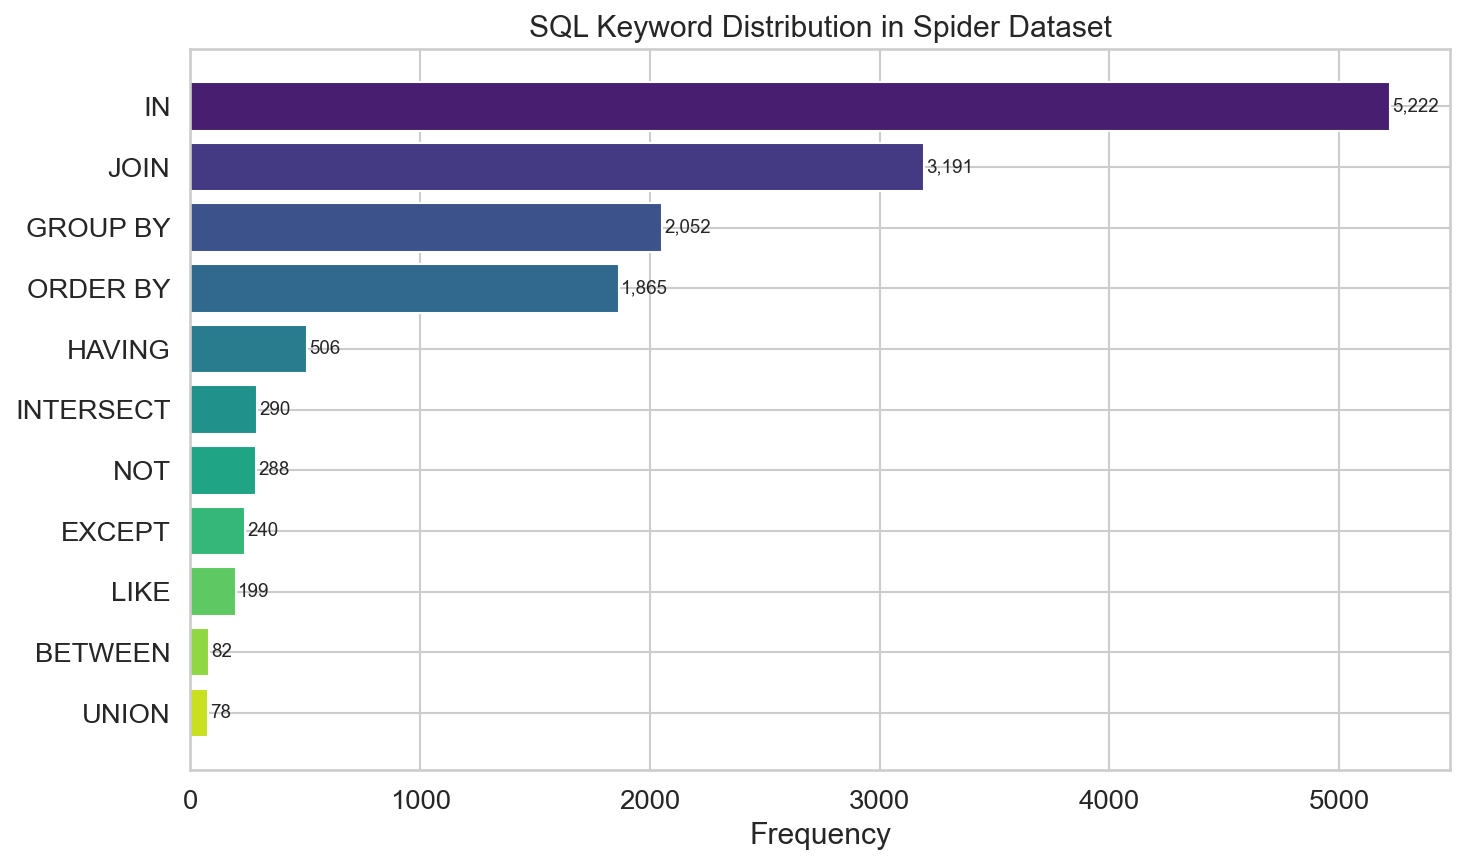

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
keywords = sorted(stats['query_keywords'].items(), key=lambda x: x[1], reverse=True)
kw_names = [k[0] for k in keywords]
kw_counts = [k[1] for k in keywords]

colors = sns.color_palette('viridis', len(kw_names))
bars = ax.barh(kw_names[::-1], kw_counts[::-1], color=colors[::-1])
ax.set_xlabel('Frequency')
ax.set_title('SQL Keyword Distribution in Spider Dataset')
for bar, count in zip(bars, kw_counts[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig1_keyword_distribution.png'), bbox_inches='tight')
plt.show()

## Figure 2: Query & Question Length Distributions

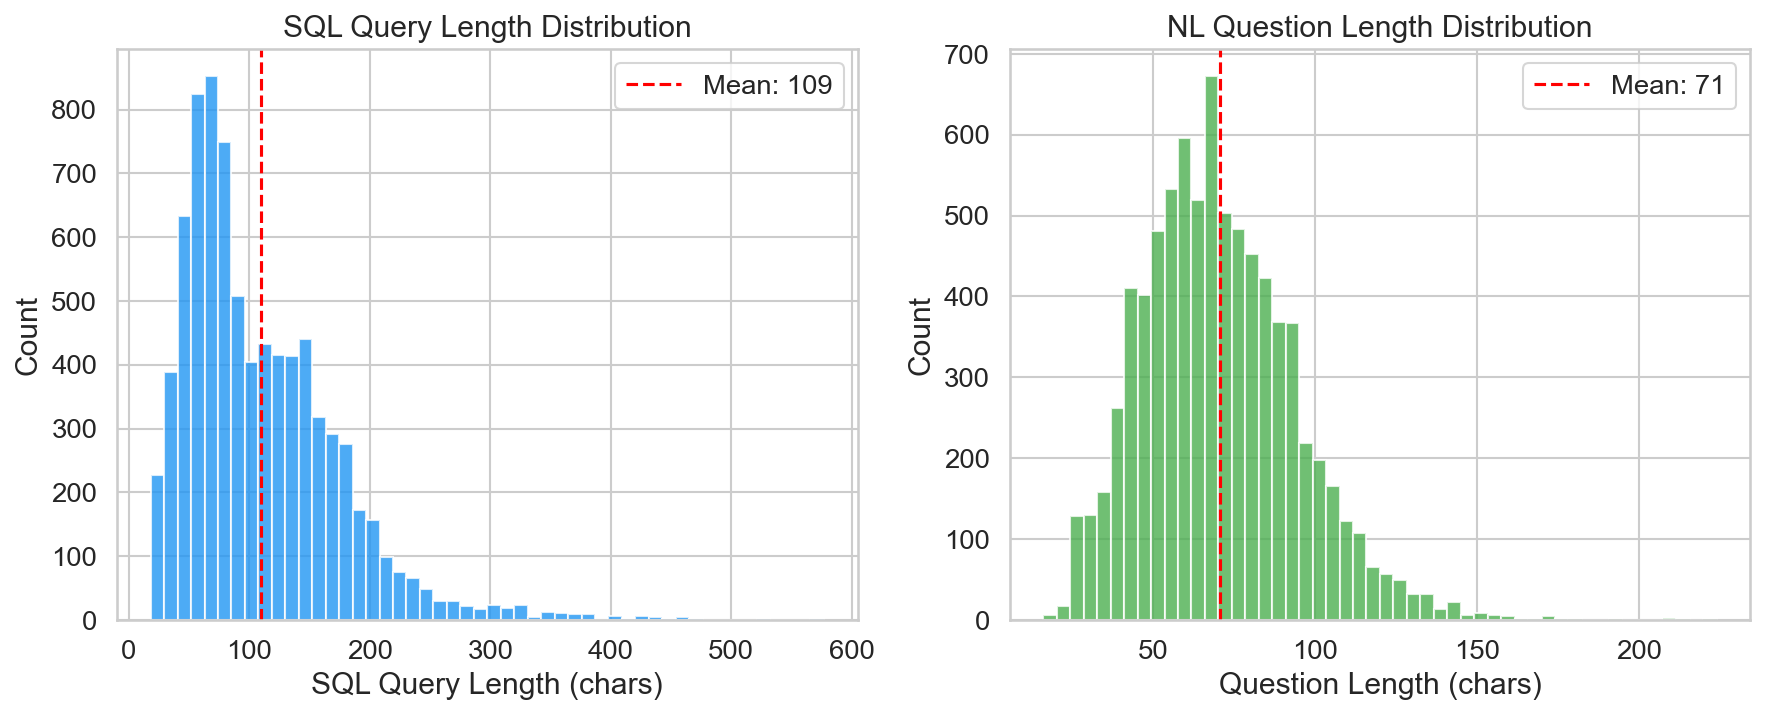

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(stats['query_lengths'], bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('SQL Query Length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('SQL Query Length Distribution')
axes[0].axvline(np.mean(stats['query_lengths']), color='red', linestyle='--',
                label=f"Mean: {np.mean(stats['query_lengths']):.0f}")
axes[0].legend()

axes[1].hist(stats['question_lengths'], bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Question Length (chars)')
axes[1].set_ylabel('Count')
axes[1].set_title('NL Question Length Distribution')
axes[1].axvline(np.mean(stats['question_lengths']), color='red', linestyle='--',
                label=f"Mean: {np.mean(stats['question_lengths']):.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig2_length_distributions.png'), bbox_inches='tight')
plt.show()

## Figure 3: Database Complexity

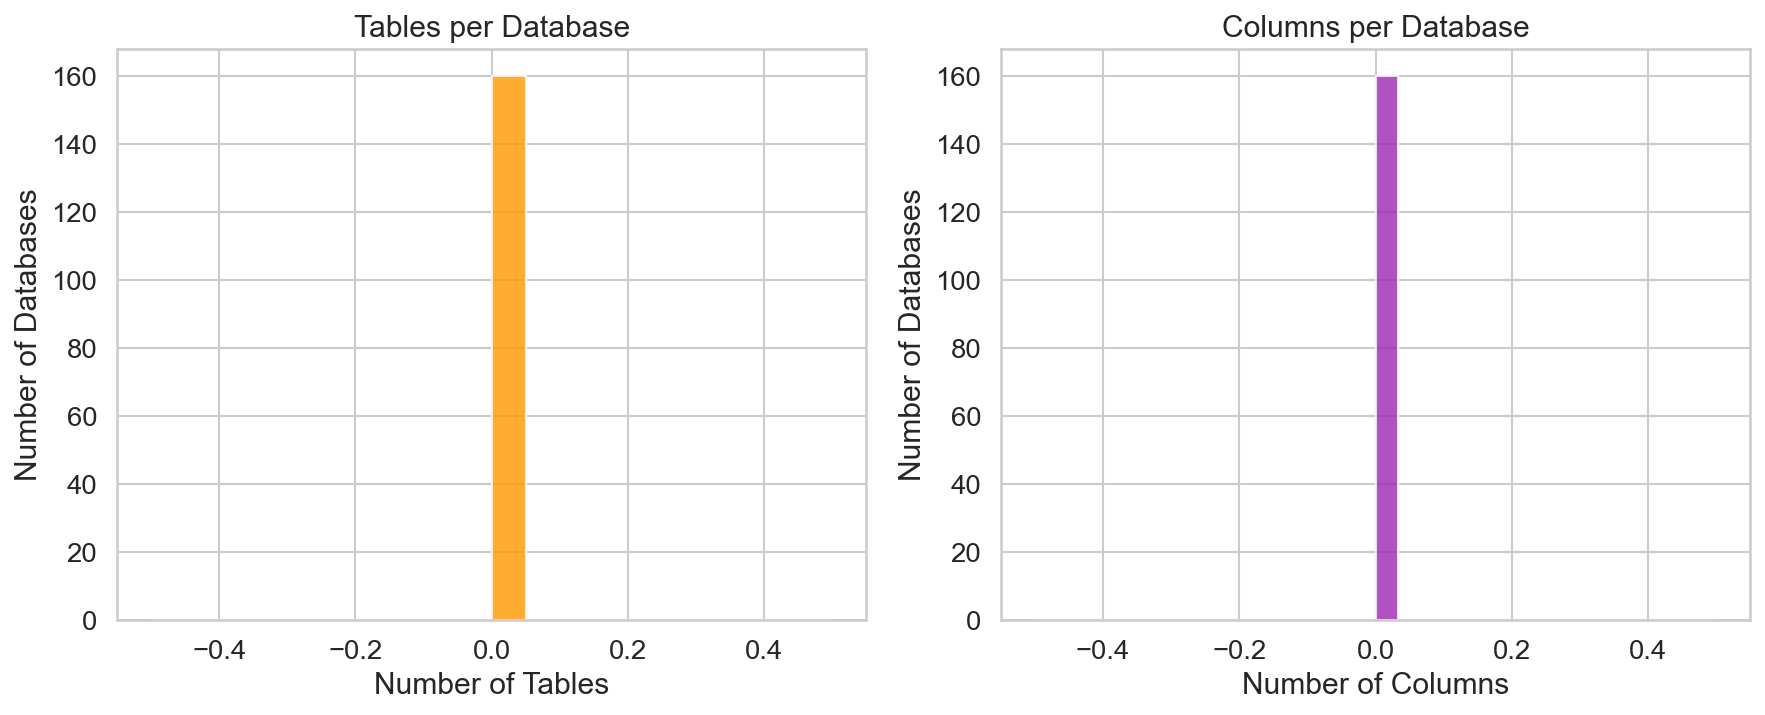

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(stats['tables_per_db'], bins=20, color='#FF9800', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Number of Tables')
axes[0].set_ylabel('Number of Databases')
axes[0].set_title('Tables per Database')

axes[1].hist(stats['cols_per_db'], bins=30, color='#9C27B0', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Number of Columns')
axes[1].set_ylabel('Number of Databases')
axes[1].set_title('Columns per Database')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_db_complexity.png'), bbox_inches='tight')
plt.show()

## Sample Formatted Prompt

In [8]:
from src.data_loader import format_example

sample = dataset['train'][0]
formatted = format_example(sample, schema_manager, config)
print(formatted['text'][:800])
if len(formatted['text']) > 800:
    print('...')

print(f"\n\nAll figures saved to: {FIGURES_DIR}")
print('EDA complete!')

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert SQL assistant. Given a database schema and a natural language question, generate the correct SQL query. Output ONLY the SQL query, nothing else.<|eot_id|><|start_header_id|>user<|end_header_id|>

Given the following database schema:



Question: How many heads of the departments are older than 56 ?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

SELECT count(*) FROM head WHERE age  >  56<|eot_id|>


All figures saved to: outputs\figures
EDA complete!
